In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better plot style
sns.set_style("whitegrid")

In [5]:
# Load the cleaned Netflix dataset into a DataFrame.

df = pd.read_csv("cleaned_netflix_data.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Understand dataset structure before analysis.

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (8797, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


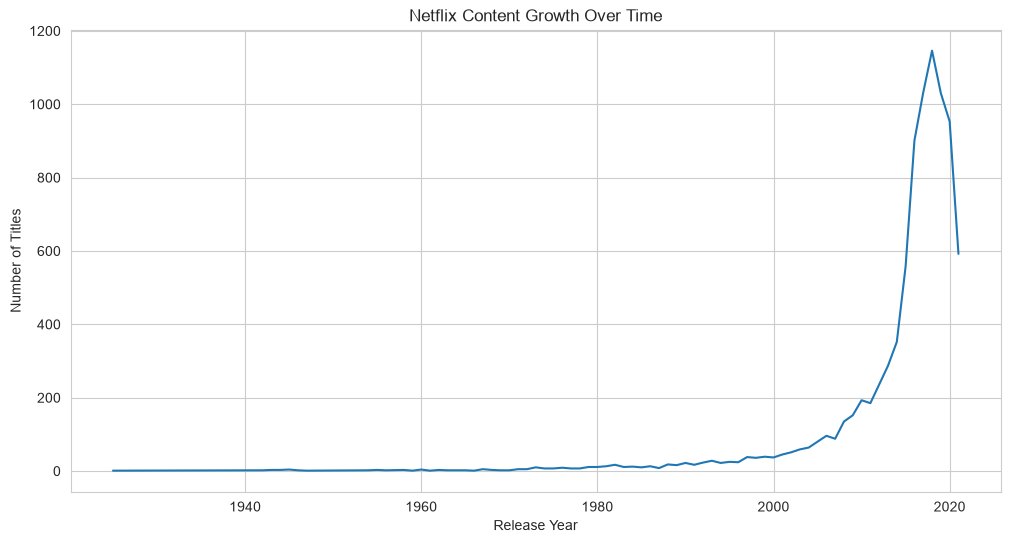

In [41]:
# Analyze how Netflix content has grown over the years.

yearly_content = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(yearly_content.index,
         yearly_content.values)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


type
Movie      6131
TV Show    2666
Name: count, dtype: int64


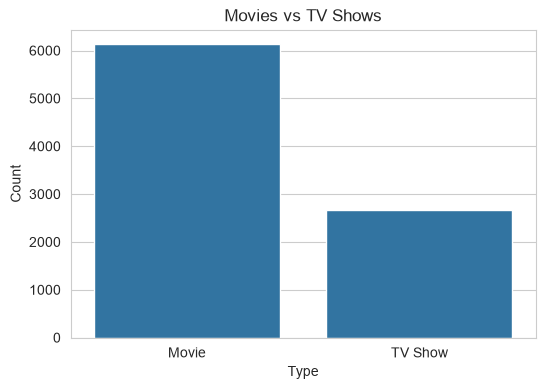

In [7]:
# Identify whether Netflix focuses more on Movies or TV Shows.

content_type = df['type'].value_counts()

print(content_type)

plt.figure(figsize=(6,4))
sns.barplot(x=content_type.index,
            y=content_type.values)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [8]:
# Identify the most popular genres on Netflix.

genre_series = df['listed_in'].str.split(',')

all_genres = genre_series.explode()

all_genres = all_genres.str.strip()

top_genres = all_genres.value_counts().head(10)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


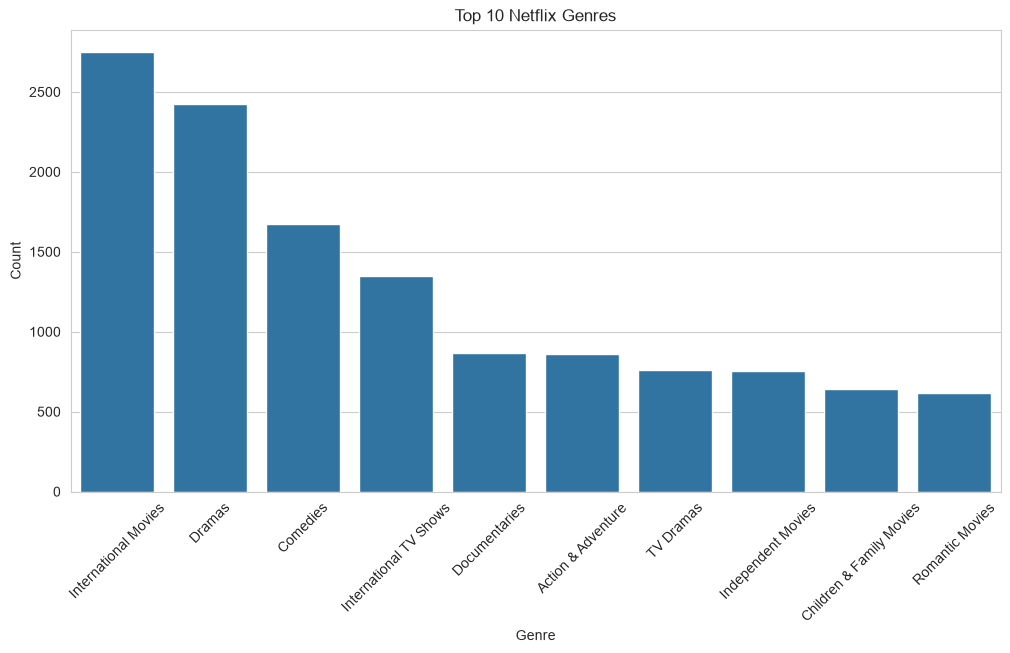

In [12]:
# Display Top 10 Netflix Genres using a vertical bar chart.

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.index,
    y=top_genres.values
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

# Rotate labels for better visibility
plt.xticks(rotation=45)

plt.show()

In [13]:
# Understand Netflix target audience using ratings.

rating_count = df['rating'].value_counts()

print(rating_count.head())

rating
TV-MA    3209
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64


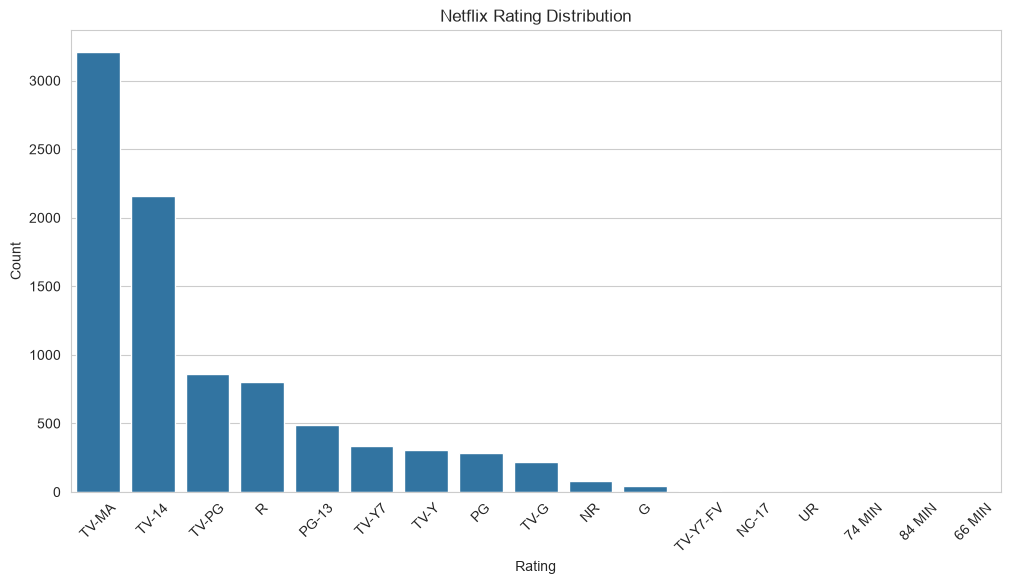

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values
)

plt.title("Netflix Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [18]:
# Identify countries contributing the most content.

country_series = df['country'].dropna().str.split(',')

all_countries = country_series.explode()

all_countries = all_countries.str.strip()

top_countries = all_countries.value_counts().head(10)

print(top_countries)

country
United States     3684
India             1046
Unknown            830
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


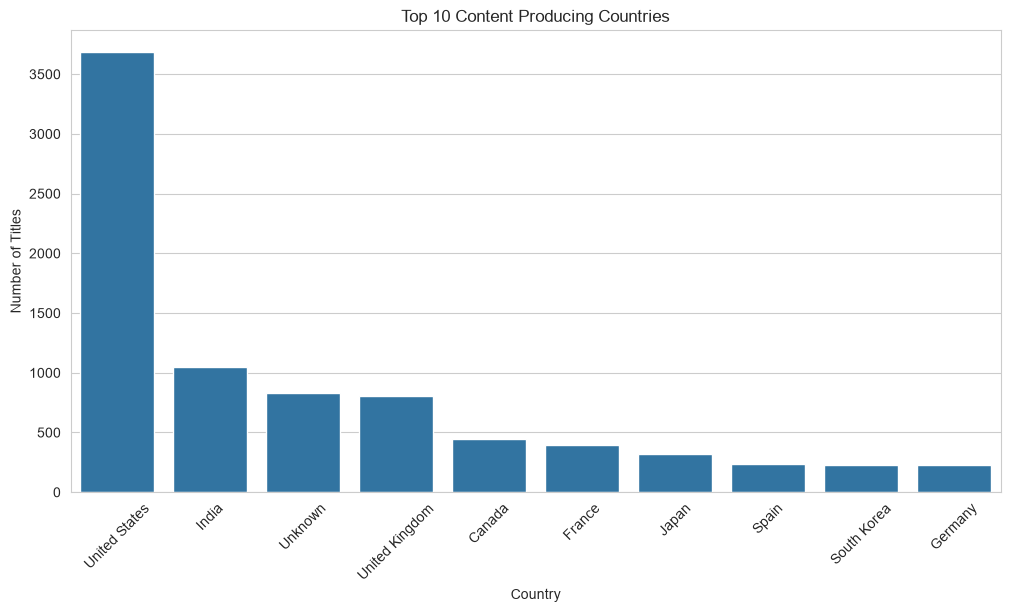

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

   duration  duration_minutes
0    90 min              90.0
6    91 min              91.0
7   125 min             125.0
9   104 min             104.0
12  127 min             127.0


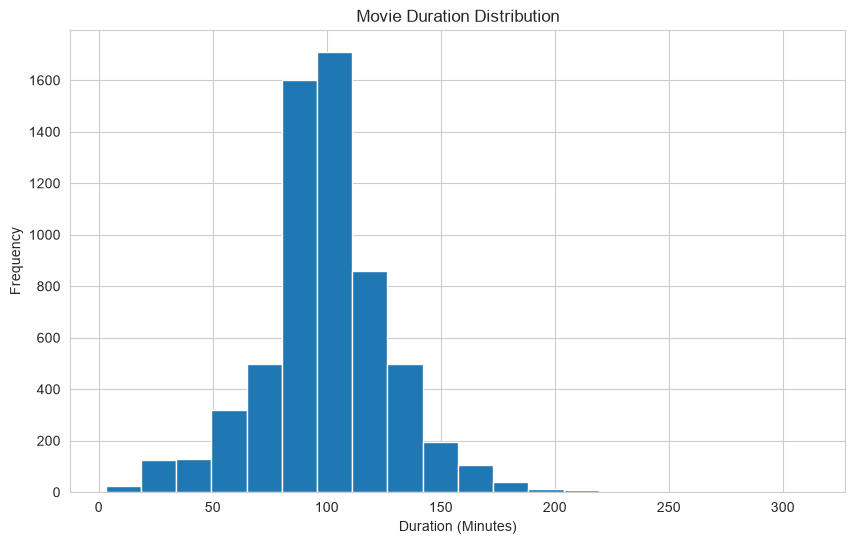

In [29]:
# Extract numeric duration values safely from movie durations.

movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_minutes'] = movie_df['duration'].str.extract(r'(\d+)')

movie_df['duration_minutes'] = pd.to_numeric(
    movie_df['duration_minutes'],
    errors='coerce'
)

movie_df = movie_df.dropna(subset=['duration_minutes'])

print(movie_df[['duration', 'duration_minutes']].head())


# Visualize movie runtime distribution.

plt.figure(figsize=(10,6))

plt.hist(
    movie_df['duration_minutes'],
    bins=20
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#Content Length Categorization

# Categorize movies into Short, Medium, Long.

def length_category(duration):

    if duration < 60:
        return "Short"

    elif duration <= 120:
        return "Medium"

    else:
        return "Long"


movie_df['content_length_category'] = (
    movie_df['duration_minutes']
    .apply(length_category)
)

movie_df[
    ['duration_minutes',
     'content_length_category']
].head()

,duration_minutes,content_length_category
0,90.0,Medium
6,91.0,Medium
7,125.0,Long
9,104.0,Medium
12,127.0,Long


In [34]:
# Determine how old each title is.

CURRENT_YEAR = 2026

df['content_age'] = (
    CURRENT_YEAR -
    df['release_year']
)

df[['title','release_year',
    'content_age']].head()

,title,release_year,content_age
0,Dick Johnson Is Dead,2020,6
1,Blood & Water,2021,5
2,Ganglands,2021,5
3,Jailbirds New Orleans,2021,5
4,Kota Factory,2021,5


In [33]:
# Group titles by decade.

df['decade'] = (
    (df['release_year']//10)*10
).astype(str) + "s"

df[['release_year',
    'decade']].head()

,release_year,decade
0,2020,2020s
1,2021,2020s
2,2021,2020s
3,2021,2020s
4,2021,2020s


In [36]:
# Count number of genres assigned to each title.

df['genre_count'] = (
    df['listed_in']
    .str.split(',')
    .apply(len)
)

df[['title','listed_in',
     'genre_count']].head()

,title,listed_in,genre_count
0,Dick Johnson Is Dead,Documentaries,1
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",3
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...",3
3,Jailbirds New Orleans,"Docuseries, Reality TV",2
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...",3


In [37]:
# Add content_length_category into original dataframe.

df = df.merge(
    movie_df[['show_id',
              'content_length_category']],
    on='show_id',
    how='left'
)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_age,decade,genre_count,content_length_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,2020s,1,Medium
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,2020s,3,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,2020s,3,NaN
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,2020s,2,NaN
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,2020s,3,NaN


In [38]:
# Save the final dataset for Milestone 3.

df.to_csv(
    "netflix_featured.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!
